### 1-1. midi 파일 전처리

In [1]:
from process import adjust_to_eighth_note, label_active_chord_by_onset, get_ready_with_lags

file_name = "Ryuichi_Sakamoto_-_hibari.mid"
adjusted_notes, tempo = adjust_to_eighth_note(file_name)

adn_1 = adjusted_notes[:2006]
adn_2 = adjusted_notes[2006:]

adn_1_real = adn_1[:-59]
adn_2_real = adn_2[59:]

adn_1_chord = label_active_chord_by_onset(adn_1_real) # 33*59
adn_2_chord = label_active_chord_by_onset(adn_2_real) # 32*59

adn_i = get_ready_with_lags(adn_1_chord, adn_2_chord)

1th instrument ending : index 2006
2th instrument ending : index 3953


c:\Users\82104\Developments\.venv\lib\site-packages\pretty_midi\pretty_midi.py:100: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


* adn_i_chord_(i = 1, 2)는 두 list에서 동시에 연주되는 범위(5~132마디)에 해당됩니다.

In [3]:
# import pandas as pd
# module_chord_label = pd.DataFrame(adn_1_chord[:32])
# module_chord_label.value_counts().to_frame()

* 곡에서 반복되는 단위를 추출하고(module_notes), 각 시점에서 활성화된 음들을 모아(active_module) 화음 단위로 정제합니다.
* 화음에 대해 3가지 방식으로 딕셔너리를 만듭니다.

In [2]:
from process import (group_notes_with_duration_, notes_label_n_counts, 
                  chord_label_to_note_labels, transform_dict, chord_label_dict)

module_notes = adn_1_real[:59]
# module_chord = adn_1_chord[:32]
active_module = group_notes_with_duration_(module_notes)

notes_label, notes_counts = notes_label_n_counts(module_notes)
chord_label = chord_label_dict(active_module)

# notes = (pitch, duration)
notes_dict = chord_label_to_note_labels(chord_label, notes_label)
# pitches_dict = transform_dict(chord_label)
# pitch_classes_dict = transform_dict(chord_label, project=True)

notes_dict['name'] = 'notes'
# pitches_dict['name'] = 'pitches'
# pitch_classes_dict['name'] = 'pitch_classes'

* 총 17개의 화음이 등장하고, 각 instrumental의 솔로 구간이 있어 17 choose 2 + 17 = 153개의 조합이 등장할 거란 예상처럼 0 ~ 152까지의 value가 발견됩니다.

In [5]:
from process import simul_chord_lists, label_simul_chords_combi

simul_chords_key = simul_chord_lists(adn_i[1][-1], adn_i[2][-1])

# simul_chord_comb_dict = label_simul_chords_combi(simul_chords_key)
# for item_set, label in simul_chord_comb_dict.items():
#     print(f"{set(item_set)}: {label}")

In [6]:
# import matplotlib.pyplot as plt

# # simul_chord_comb_dict
# labeled_list = []
# for sublist in simul_chords_key:
#     key = frozenset(sublist)  # 현재 sublist를 frozenset으로 변환
#     label = simul_chord_comb_dict[key]  # 해당 frozenset을 키로 사용하여 label 가져오기
#     labeled_list.append(label)  # label을 labeled_list에 추가

# # x축 데이터 (index) 생성
# x = list(range(len(labeled_list)))

# # 그래프 생성
# plt.plot(x, labeled_list, linestyle='-')  # marker와 linestyle을 지정하여 꺾은선 그래프 생성

# # marker='o',

# # 그래프 제목 및 축 레이블 설정
# plt.title("Labeled List Plot")
# plt.xlabel("time")
# plt.ylabel("Label")

# # 그리드 추가 (선택 사항)
# plt.grid(True)

# # 그래프 출력
# plt.show()

In [7]:
# from collections import Counter

# # Counter 객체 생성
# label_counts = Counter(labeled_list)

# frequent_labels = []
# often_labels = []
# for label, count in label_counts.items():
#     if count >= 20 :
#         # print(f"Label {label}: {count}번")
#         frequent_labels.append(label)
#     elif count >= 8 : # 8 아니면 10
#         often_labels.append(label)

In [8]:
# # frequent_chord_comb = [key for key, value in simul_chord_comb_dict.items() if value in frequent_labels]
# often_chord_comb = [key for key, value in simul_chord_comb_dict.items() if value in often_labels]

# # label 빈도를 저장할 딕셔너리 초기화
# label_counts = {i: 0 for i in range(17)}  # 0부터 16까지 label 초기화

# # label 빈도 계산
# for chord_comb in often_chord_comb:
#     for label in chord_comb:
#         # if 0 <= label <= 16:
#         label_counts[label] += 1

# # 결과 출력
# print("Label Counts:")
# for label, count in label_counts.items():
#     print(f"Label {label}: {count}번")

In [ ]:
"""
listofDimension
[1, 2, 3] : 33.2s
[1] : 0.1s
[2] : 2.2s /   '(5, 18, 19) - (9, 18, 19) + (3, 5, 19) - (3, 9, 19) + (5, 11, 18) - (9, 11, 18) - (3, 5, 11) + (3, 9, 11)']]
[3] : 36.7s /   '-(0, 5, 9, 13) + (3, 5, 9, 13) + (2, 3, 9, 13) + (0, 5, 7, 13) - (3, 5, 7, 13) - (2, 3, 7, 13) + (0, 5, 9, 10) - (3, 5, 9, 10) - (2, 3, 9, 10) - (0, 5, 7, 10) + (3, 5, 7, 10) + (2, 3, 7, 10) + (0, 1, 9, 13) + (1, 2, 9, 13) - (0, 1, 9, 10) - (1, 2, 9, 10) - (0, 1, 7, 13) - (1, 2, 7, 13) + (0, 1, 7, 10) + (1, 2, 7, 10)']]
[1, 2] : 2.1s
[2, 3] : 33.6s
"""

print("generateBarcode 실행결과")

generateBarcode 실행결과


In [22]:
import util
import importlib
importlib.reload(util)

from util import (search_timeflow_cycles, get_rBD_groupedBy_cycle, 
                  plot_cycle_BirthDeath_over_rate, split_cycles_by_consecutive,
                  cycle_rBD_to_pkl)

from util import get_chords_intra_connected

weight_mtrx_1 = get_chords_intra_connected(adn_i[1][0], lag=1)
weight_mtrx_2 = get_chords_intra_connected(adn_i[2][0], lag=1)
intra_weights = weight_mtrx_1 + weight_mtrx_2

In [23]:
power = -4
refine_dict = notes_dict

* 아래 코드를 수행하면 
* intra_weights와 inter_weight를 더해서 얻어진 timeflow_weight에 대해 UTM을 구하고 refine하는 것과
* intra_weights, inter_weight 각각에 대해 UTM을 구하고 refine한 뒤 더하는 연산이 commute함을 알 수 있다.

In [ ]:
# from util import check_commutivity
# from util import get_UTMconnected, refine_connectedness, get_distance_matrix_from, get_LTMpart_of
# from util import get_outta_reach, get_chords_inter_connected, is_distance_matrix_from

# inter_lag = 1
# inter_weight = get_chords_inter_connected(adn_i[1][inter_lag], adn_i[2][inter_lag], lag=inter_lag)
# outta_reach_t = get_outta_reach(inter_weight, power = power)

# timeflow_weight = intra_weights + inter_weight 

# """ 여기서부터  """
# # lower triangle에 있는 비대각원소를 UT로 옮깁니다(더한 뒤 0으로 만듭니다) 
# weight_UTM = get_UTMconnected(timeflow_weight)

# # 화음 단위에서 notes(pitch, length) | pitch | pitch_classes 기준으로 weight를 refine합니다
# weight_UTM = refine_connectedness(weight_UTM, refine_dict)

# # 역수 변환
# distance_UTM = get_distance_matrix_from(weight_UTM, outta_reach_t)

# distance_df = get_LTMpart_of(distance_UTM)

# """ 여기까지 is_distance_matrix_from 함수 내부 동작 """

# check_commutivity(inter_weight, intra_weights, refine_dict, outta_reach_t, distance_df)

In [3]:
# inter_lag = 4
# start = 0.0
# end = 1.5
# cycles_profile_t, outta_reach_t = search_timeflow_cycles(intra_weights, adn_i[1][inter_lag], adn_i[2][inter_lag], 
#                                                         inter_lag = inter_lag, refine_dict = refine_dict, output_dir = './power_search',
#                                                         rate_start = start, rate_end = end, power = power, loglog = True)

# cycle_persistence_t = get_rBD_groupedBy_cycle(cycles_profile_t)
# print("Total number of cycles: ", len(cycle_persistence_t))

# non_consecutive_cycles_t, consecutive_cycles_t = split_cycles_by_consecutive(cycle_persistence_t, out_of_reach = outta_reach_t, power = power)
# # plot_cycle_BirthDeath_over_rate(non_consecutive_cycles_t, subplot_in_a_row = 3, power = power)
# # plot_cycle_BirthDeath_over_rate(consecutive_cycles_t, subplot_in_a_row = 4, power = power)

# cycle_persistence_t_updated = {**non_consecutive_cycles_t, **consecutive_cycles_t}

# # 데이터프레임 변환 및 pkl파일 내보내기
# temp_t_n_5 = cycle_rBD_to_pkl(cycle_persistence_t_updated, refine_dict, inter_lag, start, end, power)

In [ ]:
plot_cycle_BirthDeath_over_rate(non_consecutive_cycles_t, subplot_in_a_row = 3, power = power)

In [30]:
for cycle in consecutive_cycles_t.keys():
    print(cycle)
    print(consecutive_cycles_t[cycle][:5])
    print("\n")

(0, 13, 8, 15)
((1.3, 0.00541711809317443, 0.005827505827505827), (1.30001, 0.005417091095754018, 0.005827494960382358), (1.30002, 0.005417064098602702, 0.005827484093299419), (1.30003, 0.005417037101720473, 0.005827473226257009), (1.30004, 0.005417010105107331, 0.00582746235925513))


(0, 15, 8, 18)
((1.3, 0.004690431519699812, 0.005827505827505827), (1.30001, 0.0046904174396474605, 0.005827494960382358), (1.30002, 0.004690403359679642, 0.005827484093299419), (1.30003, 0.004690389279796355, 0.005827473226257009), (1.30004, 0.004690375199997599, 0.00582746235925513))


(0, 6, 9, 1)
((1.3, 0.004807692307692307, 0.005827505827505827),)


(0, 6, 17, 1)
((1.3, 0.005197505197505197, 0.005827505827505827), (1.30001, 0.005197492230788613, 0.005827494960382358), (1.30002, 0.005197479264136728, 0.005827484093299419), (1.30003, 0.005197466297549541, 0.005827473226257009), (1.30004, 0.005197453331027051, 0.00582746235925513))


(2, 9, 11, 5, 3)
((1.3, 0.005060728744939272, 0.005827505827505828),)

* 반드시 rate_end = rate_start 인 두 파일에 대해서만 아래와 같이 합쳤을 때 문제가 없다!!!

In [ ]:
from util import cycle_rBD_from_pkl, merge_partial_dicts

# inter_lag = 1
# power = -5

# start = 0.0 # 0.2 # 0.4
# middle = 0.1 # 0.3 # 0.5
# end = 0.2 # 0.4 # 0.6

# # # # pkl 파일 읽기 (이전에 저장한 파일을 사용)
# pkl_file_11 = f'cycle_rBD_t_notes{inter_lag}_1e{power}_{start}~{middle}.pkl'
# cycle_persistence_t_n_4_1 = cycle_rBD_from_pkl(pkl_file_11, dir="./pickle")
# # find_differences(cycle_persistence_t_n1_, cycle_persistence_t_n1)

# pkl_file_12 = f'cycle_rBD_t_notes{inter_lag}_1e{power}_{middle}~{end}.pkl'
# cycle_persistence_t_n_4_2 = cycle_rBD_from_pkl(pkl_file_12, dir="./pickle")

# # cycle_persistence_t_n_4_1[(0, 6, 21, 1)][-1], cycle_persistence_t_n_4_2[(0, 6, 21, 1)][0]
# cycle_persistence_t_n_4 = merge_partial_dicts(cycle_persistence_t_n_4_1, cycle_persistence_t_n_4_2)

# temp = cycle_rBD_to_pkl(cycle_persistence_t_n_4, refine_dict, inter_lag, start, end, power, output_dir = "./pickle")

Pickle 파일 'cycle_rBD_t_notes4_1e-4_0.0~1.5.pkl'가 성공적으로 생성되었습니다.


In [ ]:
from util import get_chords_inter_connected, get_outta_reach

pkl_file = 'cycle_rBD_t_notes1_1e-4_0.0~1.5.pkl'
cycle_persistence_t_n1_4 = cycle_rBD_from_pkl(pkl_file, dir="./pickle")

inter_lag = 1
power = -4
inter_weight = get_chords_inter_connected(adn_i[1][inter_lag], adn_i[2][inter_lag], lag=inter_lag)
outta_reach_t_n1_4 = get_outta_reach(inter_weight, power = power)

non_consecutive_cycles_t_n1_4, _ = split_cycles_by_consecutive(cycle_persistence_t_n1_4, 
                                                               out_of_reach = outta_reach_t_n1_4, 
                                                               power = power)

In [92]:
lifes = set()
for i in range(len(non_consecutive_cycles_t_n1_4[(0, 6, 21, 1)])) :
    # 각 rate에서 death - birth를 계산하는 것
    life = non_consecutive_cycles_t_n1_4[(0, 6, 21, 1)][i][2] - non_consecutive_cycles_t_n1_4[(0, 6, 21, 1)][i][1]
    lifes.add(life)
    # print(life)

# print("\n")
print(f"cycle (0, 6, 21, 1) could persist for {len(lifes)} options in terms of its life, ")
print(f"each of which is {lifes}")


cycle (0, 6, 21, 1) could persist for 2 options in terms of its life, 
each of which is {8.673617379884035e-19, 1.734723475976807e-18}


In [17]:
lifes = set()
for i in range(len(cycle_persistence_t_n2_updated[(0, 15, 22, 1)])) :
    # 각 rate에서 death - birth를 계산하는 것
    life = cycle_persistence_t_n2_updated[(0, 15, 22, 1)][i][2] - cycle_persistence_t_n2_updated[(0, 15, 22, 1)][i][1]
    lifes.add(life)
    # print(life)

# print("\n")
print(f"cycle (0, 15, 22, 1) could persist for {len(lifes)} options in terms of its life, ")
print(f"each of which is {lifes}")


cycle (0, 15, 22, 1) could persist for 8519 options in terms of its life, 
each of which is {0.8395507386373993, 0.35709543541774735, 2.623652002096051, 2.517325982113107, 2.1472475792636487, 0.848257194978359, 0.05809797835500774, 0.1418394094256712, 0.1399845640072641, 0.08024448310452215, 1.8036715784182746, 0.019265956394875168, 0.020010272679726892, 0.10915040761015861, 0.04390225494456958, 0.02977577461561511, 0.028878012546996977, 0.02696954134219711, 0.07655527534157616, 0.07183435819644049, 0.03321068158037124, 0.02657836308222275, 0.020806393048928867, 0.018356537417886926, 0.022080545005124495, 0.049071781229713486, 0.04487323135845148, 0.03911649321113945, 0.019577232353228204, 0.02698335628377894, 0.08522799955434839, 0.028976119638414892, 0.02267714512088053, 0.021957588540132682, 0.026736440763642174, 0.27400081817130234, 0.018512758676905668, 0.02362321911965644, 0.03272296835433516, 0.027469515063344906, 0.018241933389887853, 0.173228512460014, 0.051293408929837, 0.037

In [61]:
for rBD in cycle_persistence_t_n2_updated[(0, 15, 22, 1)] :
    print(rBD)

(0.0, 0.007936507936507936, 101.0)
(0.01, 0.007926442612555486, 2.5)
(0.02, 0.007916402786573781, 1.25)
(0.04, 0.007896399241945674, 0.625)
(0.05, 0.007886435331230283, 0.5)
(0.07, 0.007866582756450597, 0.3571428571428571)
(0.08, 0.00785669390320553, 0.3125)
(0.09, 0.007846829880728186, 0.2777777777777778)
(0.1, 0.007836990595611286, 0.25)
(0.11, 0.007827175954915467, 0.22727272727272727)
(0.13, 0.007807620237351654, 0.1923076923076923)
(0.14, 0.0077978789769182775, 0.17857142857142855)
(0.15, 0.00778816199376947, 0.16666666666666666)
(0.16, 0.007778469197261979, 0.15625)
(0.17, 0.007768800497203232, 0.14705882352941174)
(0.18, 0.007759155803848542, 0.1388888888888889)
(0.19, 0.007749535027898327, 0.13157894736842105)
(0.2, 0.007739938080495357, 0.125)
(0.21, 0.0077303648732220155, 0.11904761904761904)
(0.22, 0.007720815318097591, 0.11363636363636363)
(0.23, 0.0077112893275755705, 0.10869565217391303)
(0.25, 0.007692307692307693, 0.1)
(0.26, 0.0076828518746158555, 0.09615384615384615)


In [17]:
cycles_t_n1 = []
for cycle in cycle_persistence_t_n1.keys():
    cycles_t_n1.append(cycle)
cycles_t_n1 = set(cycles_t_n1)

cycles_t_n2 = []
for cycle in cycle_persistence_t_n2.keys():
    cycles_t_n2.append(cycle)
cycles_t_n2 = set(cycles_t_n2)

cycles_t_n3 = []
for cycle in cycle_persistence_t_n3.keys():
    cycles_t_n3.append(cycle)
cycles_t_n3 = set(cycles_t_n3)

In [18]:
cycles_t_n12 = cycles_t_n1.intersection(cycles_t_n2)
cycles_t_n23 = cycles_t_n2.intersection(cycles_t_n3)
cycles_t_n13 = cycles_t_n1.intersection(cycles_t_n3)

cycles_t_n123 = cycles_t_n12.intersection(cycles_t_n3)
print(f"Lag 1, 2, 3 모두에서 발견되는 사이클 : {cycles_t_n123}")

Lag 1, 2, 3 모두에서 발견되는 사이클 : {(2, 9, 12, 5, 3), (0, 6, 9, 1), (0, 13, 8, 15), (5, 10, 9, 11), (3, 9, 16, 5), (0, 13, 9, 14, 16), (5, 13, 9, 11), (0, 19, 22, 1), (5, 11, 9, 18), (0, 15, 8, 18), (5, 11, 9, 15), (2, 9, 10, 5, 3), (0, 13, 9, 14, 18, 5), (0, 15, 22, 1), (0, 6, 9, 10, 5), (0, 5, 18, 19, 22, 1), (0, 6, 17, 1), (0, 5, 18, 14, 9, 13), (0, 5, 10, 9, 1), (5, 12, 9, 10), (5, 6, 9, 16), (0, 1, 9, 11, 5), (5, 10, 9, 13), (2, 9, 16, 5, 3), (5, 11, 9, 18, 19), (2, 9, 13, 5, 3), (5, 16, 14, 18), (2, 3, 5, 6, 9), (2, 20, 17, 6, 5, 18), (3, 9, 13, 5), (0, 1, 22, 15), (5, 10, 9, 18, 8, 15), (0, 1, 2, 18, 5), (3, 9, 10, 5), (5, 6, 9, 12), (5, 6, 9, 15), (5, 10, 9, 12), (5, 10, 9, 18), (5, 11, 9, 13), (2, 9, 11, 5, 3), (5, 11, 9, 10), (8, 13, 9, 15), (3, 9, 12, 5)}


In [19]:
print(f"Lag 2, 3에서 발견되고 1에서 발견되지 않는 사이클 : {cycles_t_n23 - cycles_t_n123}")
print(f"Lag 1, 3에서 발견되고 2에서 발견되지 않는 사이클 : {cycles_t_n13 - cycles_t_n123}")
print(f"Lag 1, 2에서 발견되고 3에서 발견되지 않는 사이클 : {cycles_t_n12 - cycles_t_n123}")

# print("\n")
print(f"Lag 1에서만 발견되는 사이클 : {cycles_t_n1 - cycles_t_n12 - cycles_t_n13}")
print(f"Lag 2에서만 발견되는 사이클 : {cycles_t_n2 - cycles_t_n12 - cycles_t_n23}")
print(f"Lag 3에서만 발견되는 사이클 : {cycles_t_n3 - cycles_t_n13 - cycles_t_n23}")

Lag 2, 3에서 발견되고 1에서 발견되지 않는 사이클 : {(0, 13, 9, 14, 16, 5), (5, 18, 14, 9, 13)}
Lag 1, 3에서 발견되고 2에서 발견되지 않는 사이클 : {(0, 6, 21, 1)}
Lag 1, 2에서 발견되고 3에서 발견되지 않는 사이클 : {(3, 9, 14, 16, 5)}
Lag 1에서만 발견되는 사이클 : {(0, 13, 9, 14, 18, 5, 16), (5, 6, 9, 18, 8, 15)}
Lag 2에서만 발견되는 사이클 : {(5, 10, 9, 15), (2, 3, 5, 9)}
Lag 3에서만 발견되는 사이클 : {(5, 16, 9, 14, 18)}


* inter_weight로만 실행했을 때

In [ ]:
from util import get_chords_inter_connected, is_distance_matrix_from, analyze_lifespans
from professor import generateBarcode


inter_weight = get_chords_inter_connected(adn_1_chord_1, adn_2_chord_1, lag=1)

oor_inter = 1 + 2 * 1 / inter_weight[inter_weight!=0].min().min() # 2
inter_distance = is_distance_matrix_from(inter_weight, notes_dict, out_of_reach = oor_inter)

birthDeath_inter = generateBarcode(mat = inter_distance.values, exactStep = True, birthDeathSimplex=False, sortDimension=False)
cycle_profile_inter = [(1e+6, birthDeath_inter)]
cycles_info_inter = analyze_lifespans(cycle_profile_inter, out_of_reach = 1)
cycle_persistence_inter = get_rBD_groupedBy_cycle(cycle_profile_inter)

for cycle, rBD in cycle_persistence_inter.items():
    for rate, birth, death in rBD :
        print(f"{cycle} : {round(birth, 6)} - {round(death, 6)}")

(5, 10, 9, 12) : 0.006623 - 0.007353
(5, 10, 9, 13) : 0.007143 - 0.007353
(0, 7, 5, 9) : 0.010638 - 0.01087
(1, 9, 10, 7) : 0.010417 - 0.01087
(6, 9, 10, 7) : 0.010417 - 0.01087
(2, 7, 10, 9, 13) : 0.010417 - 0.011364
(3, 10, 7, 12) : 0.013158 - 0.013889
(0, 4, 2, 7) : 0.010989 - 0.015625
(2, 4, 3, 10, 7) : 0.01087 - 0.015625
(0, 4, 3, 13) : 0.013889 - 0.015625
(1, 4, 2, 7) : 0.01087 - 0.015625
(0, 17, 8, 9) : 0.020833 - 0.025
(0, 9, 8, 21) : 0.03125 - 0.035714
(0, 9, 8, 22) : 0.03125 - 0.035714


In [21]:
simul_cycles = []
for simul_cycle in cycle_persistence_inter.keys():
    simul_cycles.append(simul_cycle)

cycle_persistence_t_n1 = get_rBD_groupedBy_cycle(cycles_profile_t_n1)
timeflow_cycles_n1 = []
for cycle in cycle_persistence_t_n1.keys():
    timeflow_cycles_n1.append(cycle)

set(timeflow_cycles_n1).intersection(set(simul_cycles))

{(5, 10, 9, 12), (5, 10, 9, 13)}

* 생각보다 적게 나온다.

* cycle_profile에 저장되어있는 정보를 딕셔너리로 정제합니다.
* key : 사이클을 구성하는 vertex들을 가장 작은 정수로 레이블링된 것부터 연결된 순서대로 나열
* value : 해당 사이클이 발견된 시점에 대해 (rate, birth, death) tuple를 담은 리스트

* 같은 vertex로 구성되어 있지만 inter_weight와 intra_weight의 비율이 변함에 따라 연결 순서가 달라지는 경우가 5건 관찰됩니다.
* generateBarcode 함수에서 DeathSimplex를 분석하는 기능을 이용해 어떻게 이럴 수 있는지 확인할 예정입니다.
* 2, 3번째 경우는 중간에 해당 Vertices 조합으로 사이클이 나타나지 않는 구간이 있는 반면 1, 4, 5번째 경우는 연속적이어서 DeathSimplex가 동일하지 않을까 예상됩니다.

In [ ]:
from util import check_rearranged_cycles

# 동일 Cycle 확인 함수 호출
rearranged_cycles = check_rearranged_cycles(cycle_persistence_t_n1)

* 사이클 갯수에 대한 위의 plot은 대강 0.03, 0.5, 0.65, 0.95를 기점으로 계단이 나뉘고 진동을 하고 있었다.

* 아주 잠깐씩 나타나던 (0, 6, 21, 1)은 rate에 따라 BirthDeath는 달라지는데
* 확인해보면 life 길이의 고윳값(eigenvalue X unique() O)이 2개뿐이어서
* 왜 이런지 이해가 필요하다, getBarcode에서 exactStep = True 옵션으로 했는데...

In [111]:
for rBD in cycle_persistence_t_n1[(0, 6, 21, 1)][:5] :
    print(rBD)

(0.03, 0.007883948281299274, 0.007883948281299276)
(0.13, 0.00771366862079605, 0.007713668620796052)
(0.22, 0.007566585956416465, 0.007566585956416467)
(0.24, 0.007534659433393611, 0.007534659433393613)
(0.31, 0.007425007425007425, 0.007425007425007426)


In [210]:
lifes = set()
for i in range(len(cycle_persistence_t_n1[(0, 6, 21, 1)])) :
    # 각 rate에서 death - birth를 계산하는 것
    life = cycle_persistence_t_n1[(0, 6, 21, 1)][i][2] - cycle_persistence_t_n1[(0, 6, 21, 1)][i][1]
    lifes.add(life)
    # print(life)

# print("\n")
print(f"cycle (0, 6, 21, 1) could persist for {len(lifes)} options in terms of its life, ")
print(f"each of which is {lifes}")


cycle (0, 6, 21, 1) could persist for 2 options in terms of its life, 
each of which is {8.673617379884035e-19, 1.734723475976807e-18}


on rate 0.0...
on rate 0.1...
on rate 0.2...
on rate 0.3...
on rate 0.4...
on rate 0.5...
on rate 0.6...
on rate 0.7...
on rate 0.8...
on rate 0.9...
on rate 1.0...
on rate 1.1...
on rate 1.2...
on rate 1.3...
on rate 1.4...


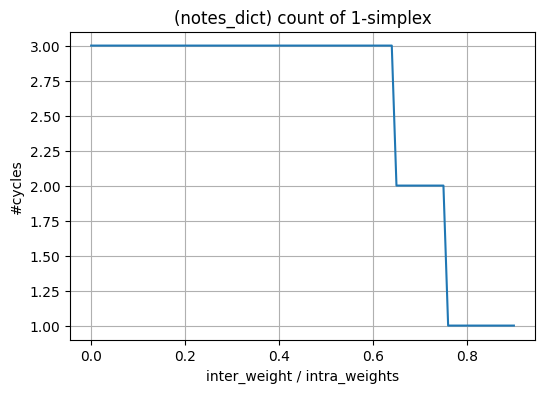

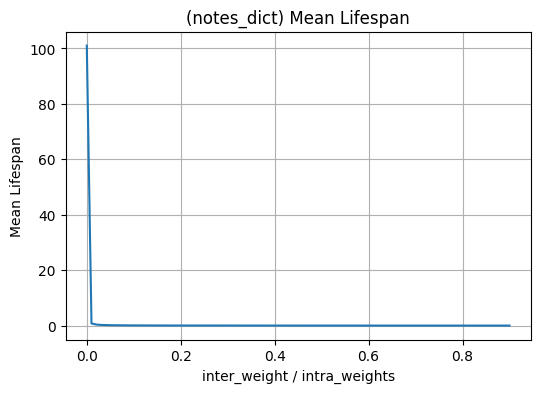

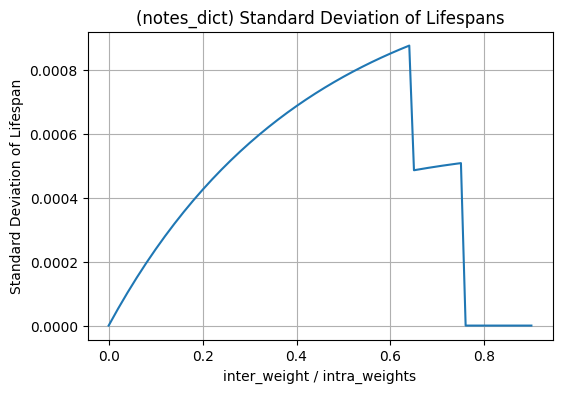

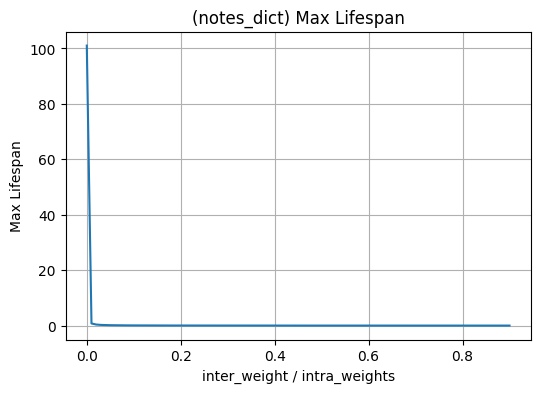

In [ ]:
from util import search_simul_cycles

cycles_profile_s, outta_reach_s = search_simul_cycles(adn_i[1][-1], adn_i[2][-1], refine_dict=notes_dict)

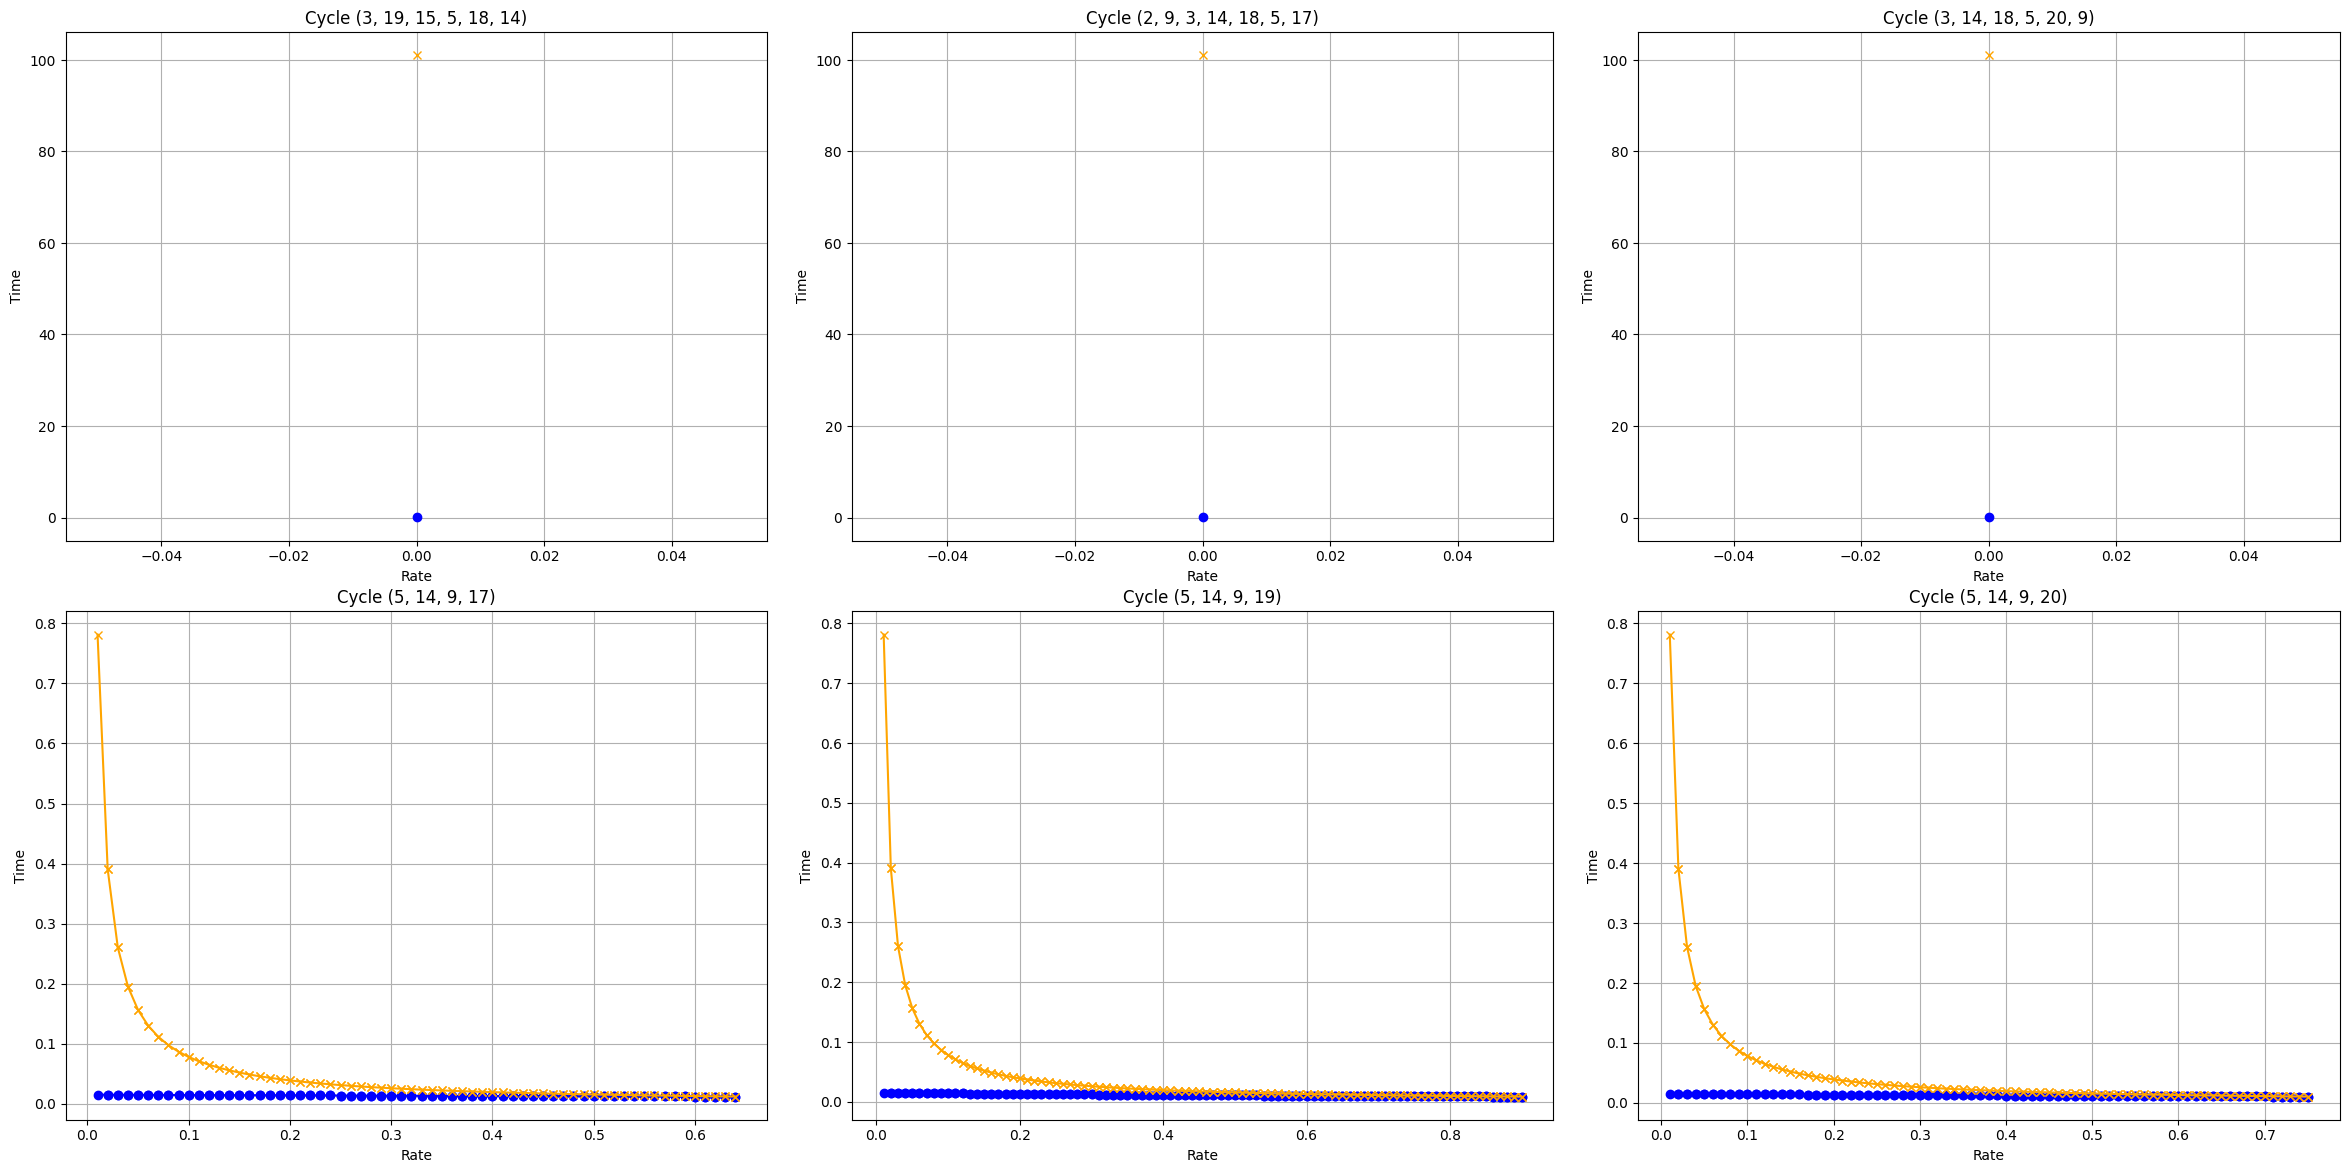

In [24]:
cycle_persistence_s = get_rBD_groupedBy_cycle(cycles_profile_s)

non_consecutive_cycles_s, consecutive_cycles_s = split_cycles_by_consecutive(cycle_persistence_s, out_of_reach = outta_reach_s, step = 0.01)
plot_cycle_BirthDeath_over_rate(consecutive_cycles_s, subplot_in_a_row = 3)

In [25]:
cycle_persistence_s.keys()

dict_keys([(3, 19, 15, 5, 18, 14), (2, 9, 3, 14, 18, 5, 17), (3, 14, 18, 5, 20, 9), (5, 14, 9, 17), (5, 14, 9, 19), (5, 14, 9, 20)])

* 악보 전체 범위에 대한 Chord labelled list (simul_whole_c)를 만들고, notes_dict를 이용해 note labelling을 해줍니다.
* inst 1은 마지막 4마디에 쉬고, inst 2는 처음 4마디를 쉽니다. 

In [ ]:
from process import simul_chord_lists
from util import simul_union_by_dict

simul_whole_c = simul_chord_lists(adn_i[1][0], adn_i[2][0])
simul_notes = simul_union_by_dict(simul_whole_c, notes_dict)

print("At First bar, inst 1 playes solo", simul_notes[0:5])
print("At Fifth bar, inst 1 & 2 play   ", simul_notes[32:37])

# print(simul_notes[:32] == simul_notes[-32:]) # True (firth 4 and last 4 bars are played solo)
# print(simul_notes[:33] == simul_notes[-33:]) # False

At First bar, inst 1 playes solo [{9, 15, 6, 1}, {9, 19, 6, 1}, {16, 2, 20, 7}, {2, 23, 7}, {10, 18, 3, 22}]
At Fifth bar, inst 1 & 2 play    [{9, 15, 6, 1}, {1, 6, 9, 15, 19}, {1, 2, 6, 7, 9, 16, 19, 20}, {16, 2, 7, 20, 23}, {18, 3, 2, 7, 22, 23, 10}]


In [21]:
from util import label_cycle

cycle_labeled, length_counts, note_counts = label_cycle(cycle_persistence_t_n1, transform_dict = notes_dict, log = True)

Cycle 길이별 개수:
Length 4: 28개
Length 5: 15개
Length 6: 7개
Length 7: 1개

Component별 포함된 사이클 개수:
Note 5: 40개
Note 9: 40개
Note 0: 18개
Note 18: 17개
Note 1: 13개
Note 10: 12개
Note 3: 11개
Note 13: 11개
Note 6: 10개
Note 15: 10개
Note 11: 9개
Note 2: 8개
Note 16: 7개
Note 22: 6개
Note 14: 6개
Note 8: 5개
Note 12: 5개
Note 19: 4개
Note 17: 2개
Note 20: 1개
Note 21: 1개

component label not in any cycle : {4, 23, 7}
where there are 23 components (notes_dict의 경우 인덱스가 1부터 시작합니다)


Correlation between plausible ratio and cycle length: 0.29012039269996
Correlation between plausible ratio and mean of vertex freq: 0.1918485139632382
Correlation between cycle length and mean of vertex freq: 0.3909526052235316


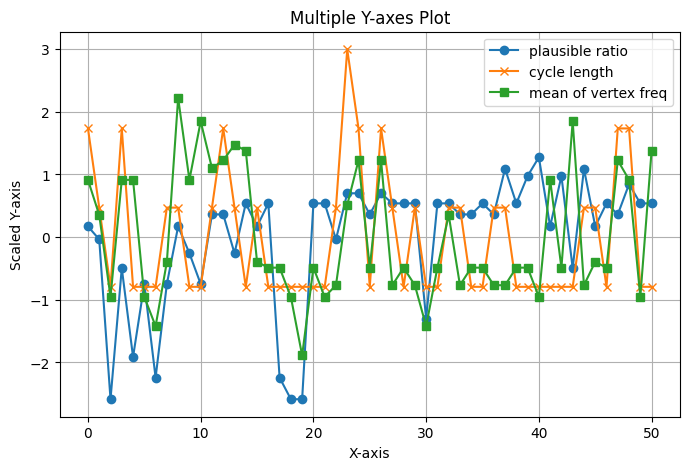

[(0, 0.8455882352941176, 6, 3.5),
 (1, 0.8207720588235294, 5, 3.2),
 (2, 0.5147058823529411, 4, 2.5),
 (3, 0.765625, 6, 3.5),
 (4, 0.5955882352941176, 4, 3.5)]

In [ ]:
from util import get_correct_df, get_scattered_cycles_df

simul_notes = simul_union_by_dict(simul_whole_c, notes_dict)
hibari_notes_df = get_correct_df(notes_dict, simul_notes)
cycles_weak = get_scattered_cycles_df(df = hibari_notes_df, cycle_labeled = cycle_labeled, weak = True)

# 위에도 있는데 너무 멀어서 다시 가져옴
module_notes = adn_1_real[:59]
active_module = group_notes_with_duration_(module_notes)
notes_label, notes_counts = notes_label_n_counts(module_notes)

from util import notes_label_counts, analyze_cycles_scattered #, check_ratio_of_on

notes_freq = notes_label_counts(notes_label, notes_counts)
plausible = analyze_cycles_scattered(cycles_weak, cycle_labeled, notes_freq, scale = True)
plausible[:5] # (column_idx, ratio, cycle_length, average_freq)

In [31]:
# notes_freq_ = sorted(notes_freq.items(), key=lambda item: item[1])
# notes_freq_

* 실제로 등장하는지 판단할 수치적인 기준?
* 시각화할 방법 : 전부 등장하는 구간 몇 개 골라서 색칠해놓기
* 어느 사이클에도 포함되지 않은 녀석들의 모듈 내 빈도수와 몇 번 화음에 포함되어 있는지